In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 5")

## Section 1 : Import Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Plot styling
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Color palette
COLORS = {'Yes': '#E74C3C', 'No': '#2ECC71', 'pos': '#E74C3C', 'neg': '#2ECC71'}
print('Libraries loaded successfully')

Libraries loaded successfully


## Section 2 : Load Data

In [5]:
# Load the dataset
df = pd.read_csv(r"D:\FQL\PJ 5\osteoporosis.csv")

In [6]:
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset Shape: 1958 rows × 16 columns


In [7]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [8]:
# Drop ID column
df.drop(columns=['ID'], inplace=True, errors='ignore')

In [9]:
df.head()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


## Section 3 : Data Overview

In [10]:
print('DATASET INFO')
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64

In [11]:
print('\n--- Statistical Summary (Numerical) ---')
df.describe()


--- Statistical Summary (Numerical) ---


,Id,Age,Osteoporosis
count,1958.000000,1958.000000,1958.000000
mean,105515.320735,39.101124,0.500000
std,2589.407806,21.355424,0.500128
min,101008.000000,18.000000,0.000000
25%,103348.500000,21.000000,0.000000
50%,105469.000000,32.000000,0.500000
75%,107755.000000,53.000000,1.000000
max,109996.000000,90.000000,1.000000


In [12]:
print('\n--- Statistical Summary (Categorical) ---')
df.describe(include='object')


--- Statistical Summary (Categorical) ---


,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures
count,1958,1958,1958,1958,1958,1958,1958,1958,1958,970,1311,973,1958
unique,2,2,2,3,2,2,2,2,2,1,2,1,2
top,Male,Normal,No,African American,Normal,Low,Sufficient,Active,Yes,Moderate,Hyperthyroidism,Corticosteroids,Yes
freq,992,981,998,681,1027,1004,1011,1021,982,970,678,973,983


In [13]:
report = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulls':   df.isnull().sum(),
    'null_%':  (df.isnull().mean()*100).round(2),
    'unique':  df.nunique(),
})

In [14]:
print('======= Quality Report =======')
display(report)
print(f'Duplicate rows: {df.duplicated().sum()}')

======= Quality Report =======


,dtype,nulls,null_%,unique
Id,int64,0,0.00,1749
Age,int64,0,0.00,73
Gender,object,0,0.00,2
Hormonal Changes,object,0,0.00,2
Family History,object,0,0.00,2
Race/Ethnicity,object,0,0.00,3
Body Weight,object,0,0.00,2
Calcium Intake,object,0,0.00,2
Vitamin D Intake,object,0,0.00,2
Physical Activity,object,0,0.00,2


Duplicate rows: 0


## Section 4 : Missing Values Analysis

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

                     Missing Count  Missing %
Alcohol Consumption            988  50.459653
Medical Conditions             647  33.043922
Medications                    985  50.306435


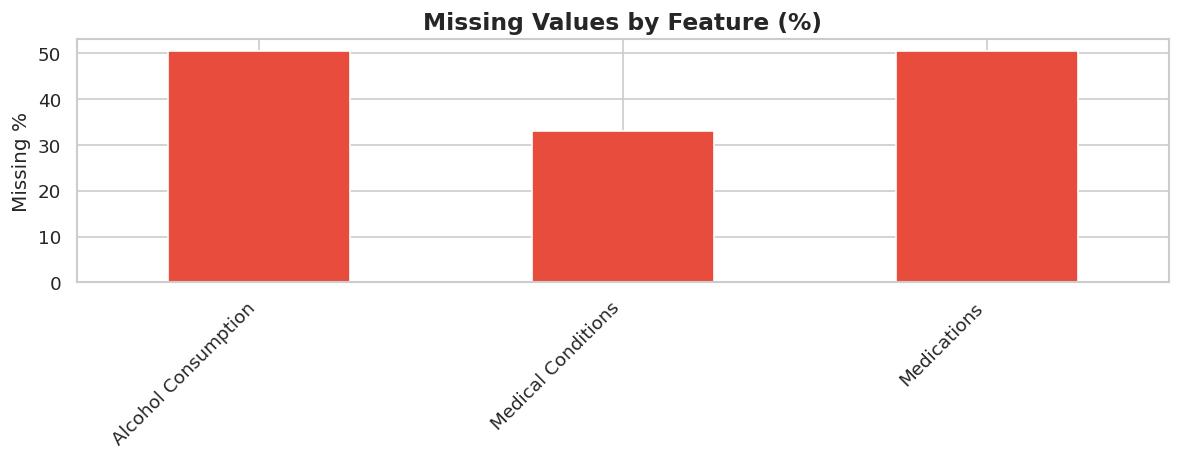

In [16]:
if missing_df.empty:
    print('No missing values found in the dataset!')
else:
    print(missing_df)
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='#E74C3C')
    ax.set_title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## section 5 : Target Variable distribution

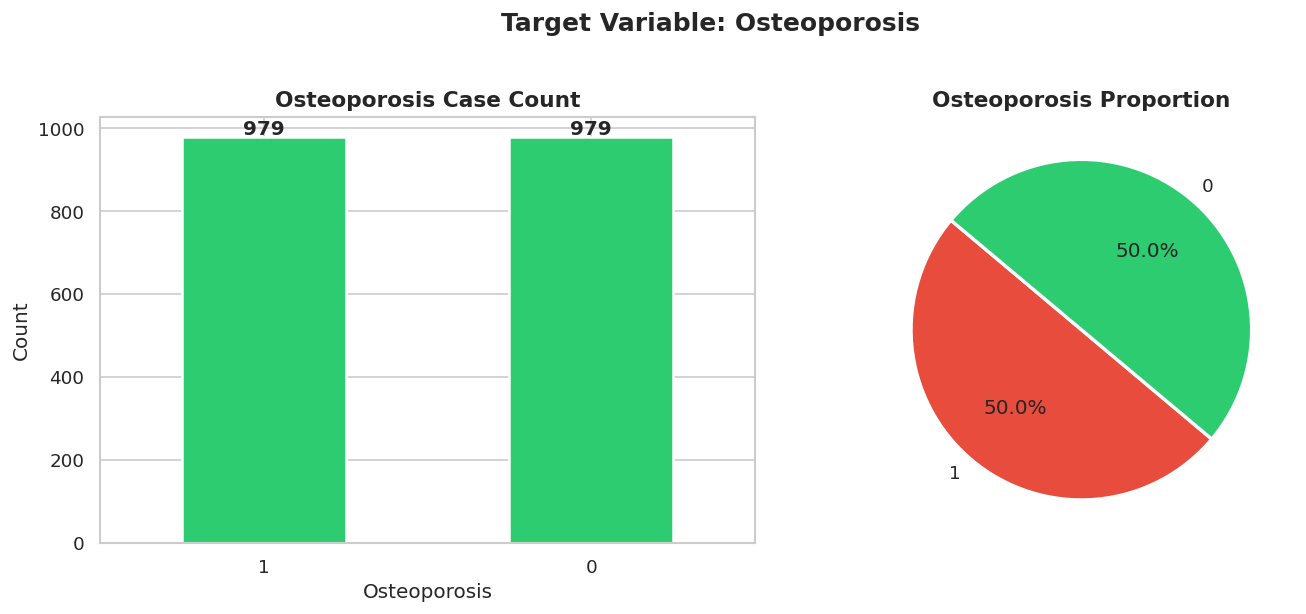

Class Distribution:
Osteoporosis
1    50.0
0    50.0
Name: proportion, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['Osteoporosis'].value_counts()
target_pct = df['Osteoporosis'].value_counts(normalize=True) * 100

# Bar chart
colors = ['#E74C3C' if x == 'Yes' else '#2ECC71' for x in target_counts.index]
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Osteoporosis Case Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Osteoporosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=['#E74C3C', '#2ECC71'], startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Osteoporosis Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Osteoporosis', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('plot/01_target_variable.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'Class Distribution:\n{target_pct.round(2)}')

## Section 6 : Univariate Analysis

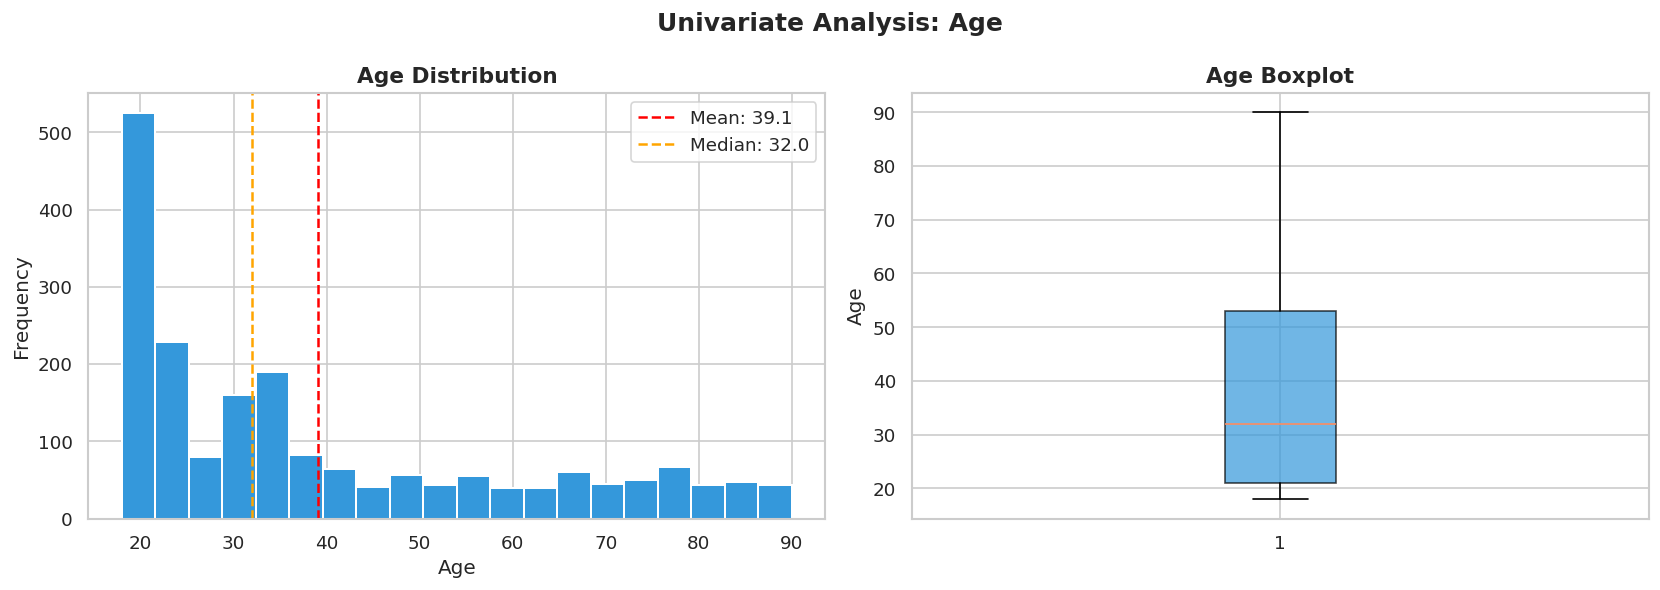

In [18]:
# --- Age Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=20, color='#3498DB', edgecolor='white', linewidth=1.2)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='orange', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(df['Age'], patch_artist=True, boxprops=dict(facecolor='#3498DB', alpha=0.7))
axes[1].set_title('Age Boxplot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('Univariate Analysis: Age', fontsize=15, fontweight='bold')
plt.savefig('plot/02_age_analysis.png', bbox_inches='tight')
plt.tight_layout()
plt.show()